In [1]:
# pip install category-encoders

In [2]:
# !pip install keras-tuner

In [3]:
# pip install pandas


In [4]:
# !pip install numpy

In [5]:
# !pip install scikit-learn

In [6]:
# !pip install tensorflow

In [7]:
# !pip install matplotlib

In [8]:
# %pip install matplotlib

In [9]:
# %pip install seaborn


In [10]:
# %pip install scikit-learn

In [11]:
# %pip install category_encoders

In [12]:
# %pip install keras_tuner

In [13]:
# %pip install tensorflow

In [14]:
### Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from category_encoders import TargetEncoder
import keras_tuner as kt
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, LeakyReLU
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.initializers import HeNormal, GlorotNormal, RandomUniform
from tensorflow.keras.regularizers import l2
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
import shutil

shutil.rmtree('kt_tuning', ignore_errors=True)


In [15]:
# dataset_Porter

In [16]:
### Load Data
data = pd.read_csv('dataset_Porter.csv')

In [17]:
### Display first few rows
display(data.head())

,market_id,created_at,actual_delivery_time,store_id,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_partners,total_busy_partners,total_outstanding_orders
0,1.0,2015-02-06 22:24:17,2015-02-06 23:27:16,df263d996281d984952c07998dc54358,american,1.0,4,3441,4,557,1239,33.0,14.0,21.0
1,2.0,2015-02-10 21:49:25,2015-02-10 22:56:29,f0ade77b43923b38237db569b016ba25,mexican,2.0,1,1900,1,1400,1400,1.0,2.0,2.0
2,3.0,2015-01-22 20:39:28,2015-01-22 21:09:09,f0ade77b43923b38237db569b016ba25,NaN,1.0,1,1900,1,1900,1900,1.0,0.0,0.0
3,3.0,2015-02-03 21:21:45,2015-02-03 22:13:00,f0ade77b43923b38237db569b016ba25,NaN,1.0,6,6900,5,600,1800,1.0,1.0,2.0
4,3.0,2015-02-15 02:40:36,2015-02-15 03:20:26,f0ade77b43923b38237db569b016ba25,NaN,1.0,3,3900,3,1100,1600,6.0,6.0,9.0


In [18]:
### Data structure and basic info
display(data.info())
display(data.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 197428 entries, 0 to 197427
Data columns (total 14 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   market_id                 196441 non-null  float64
 1   created_at                197428 non-null  object 
 2   actual_delivery_time      197421 non-null  object 
 3   store_id                  197428 non-null  object 
 4   store_primary_category    192668 non-null  object 
 5   order_protocol            196433 non-null  float64
 6   total_items               197428 non-null  int64  
 7   subtotal                  197428 non-null  int64  
 8   num_distinct_items        197428 non-null  int64  
 9   min_item_price            197428 non-null  int64  
 10  max_item_price            197428 non-null  int64  
 11  total_onshift_partners    181166 non-null  float64
 12  total_busy_partners       181166 non-null  float64
 13  total_outstanding_orders  181166 non-null  f

None

,market_id,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_partners,total_busy_partners,total_outstanding_orders
count,196441.000000,196433.000000,197428.000000,197428.000000,197428.000000,197428.000000,197428.000000,181166.000000,181166.000000,181166.000000
mean,2.978706,2.882352,3.196391,2682.331402,2.670791,686.218470,1159.588630,44.808093,41.739747,58.050065
std,1.524867,1.503771,2.666546,1823.093688,1.630255,522.038648,558.411377,34.526783,32.145733,52.661830
min,1.000000,1.000000,1.000000,0.000000,1.000000,-86.000000,0.000000,-4.000000,-5.000000,-6.000000
25%,2.000000,1.000000,2.000000,1400.000000,1.000000,299.000000,800.000000,17.000000,15.000000,17.000000
50%,3.000000,3.000000,3.000000,2200.000000,2.000000,595.000000,1095.000000,37.000000,34.000000,41.000000
75%,4.000000,4.000000,4.000000,3395.000000,3.000000,949.000000,1395.000000,65.000000,62.000000,85.000000
max,6.000000,7.000000,411.000000,27100.000000,20.000000,14700.000000,14700.000000,171.000000,154.000000,285.000000


In [19]:
### Feature Engineering
# Convert timestamps to datetime format
data['created_at'] = pd.to_datetime(data['created_at'])
data['actual_delivery_time'] = pd.to_datetime(data['actual_delivery_time'])

In [20]:
### Create target column: delivery_time_in_minutes
data['delivery_time_in_minutes'] = (data['actual_delivery_time'] - data['created_at']).dt.total_seconds() / 60

In [21]:
### Extract hour of the day and day of the week
data['order_hour'] = data['created_at'].dt.hour
data['order_day'] = data['created_at'].dt.dayofweek

In [22]:
### Feature interactions
data['order_to_partner_ratio'] = data['total_outstanding_orders'] / (data['total_onshift_partners'] + 1)

In [23]:
### Handling null values
data.replace([np.inf, -np.inf], np.nan, inplace=True)  # Convert infinite values to NaN
data.dropna(inplace=True)  # Drop remaining NaN values

In [24]:
### Encoding categorical column using Target Encoding
encoder = TargetEncoder()
data['store_primary_category'] = encoder.fit_transform(data['store_primary_category'], data['delivery_time_in_minutes'])

In [25]:
### Ensure all columns are numeric
print("Columns after encoding:", data.dtypes)

Columns after encoding: market_id                          float64
created_at                  datetime64[ns]
actual_delivery_time        datetime64[ns]
store_id                            object
store_primary_category             float64
order_protocol                     float64
total_items                          int64
subtotal                             int64
num_distinct_items                   int64
min_item_price                       int64
max_item_price                       int64
total_onshift_partners             float64
total_busy_partners                float64
total_outstanding_orders           float64
delivery_time_in_minutes           float64
order_hour                           int32
order_day                            int32
order_to_partner_ratio             float64
dtype: object


In [26]:
### Drop store_id column
data.drop(columns=['store_id'], inplace=True, errors='ignore')

In [27]:
### Ensure all columns are numeric
print("Columns after encoding:", data.dtypes)


Columns after encoding: market_id                          float64
created_at                  datetime64[ns]
actual_delivery_time        datetime64[ns]
store_primary_category             float64
order_protocol                     float64
total_items                          int64
subtotal                             int64
num_distinct_items                   int64
min_item_price                       int64
max_item_price                       int64
total_onshift_partners             float64
total_busy_partners                float64
total_outstanding_orders           float64
delivery_time_in_minutes           float64
order_hour                           int32
order_day                            int32
order_to_partner_ratio             float64
dtype: object


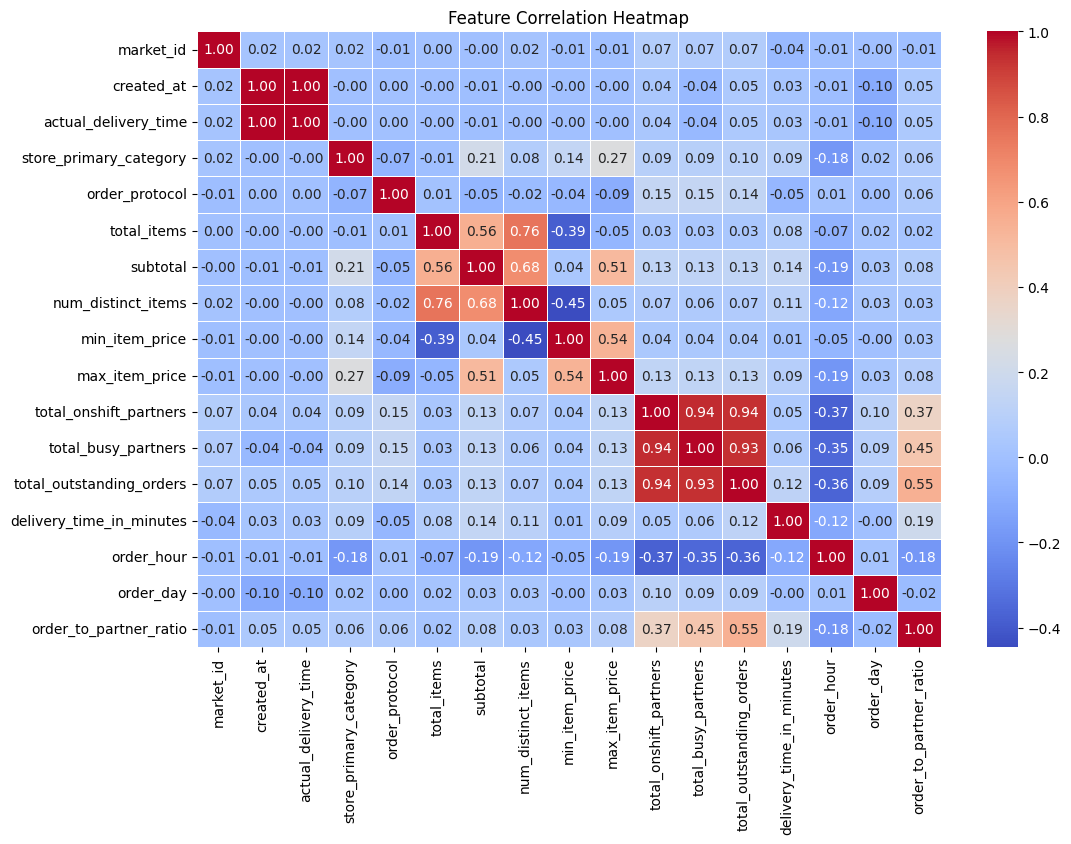

In [28]:
### Correlation Heatmap
plt.figure(figsize=(12, 8))
corr_matrix = data.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()

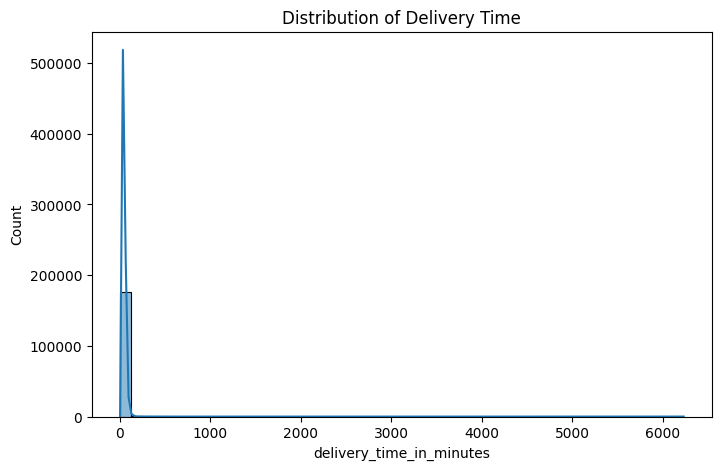

In [29]:
### Data visualization
plt.figure(figsize=(8, 5))
sns.histplot(data['delivery_time_in_minutes'], bins=50, kde=True)
plt.title('Distribution of Delivery Time')
plt.show()


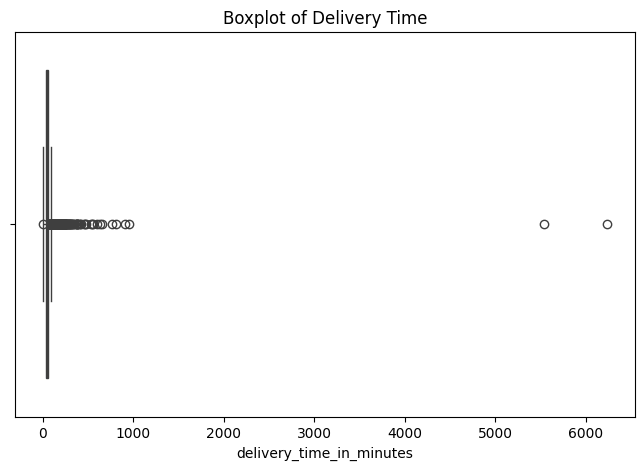

In [30]:
### Checking for outliers
plt.figure(figsize=(8, 5))
sns.boxplot(x=data['delivery_time_in_minutes'])
plt.title('Boxplot of Delivery Time')
plt.show()


In [31]:
### Outlier removal using IQR
Q1 = data['delivery_time_in_minutes'].quantile(0.25)
Q3 = data['delivery_time_in_minutes'].quantile(0.75)
IQR = Q3 - Q1

In [32]:
filtered_data = data[(data['delivery_time_in_minutes'] >= (Q1 - 1.5 * IQR)) & 
                      (data['delivery_time_in_minutes'] <= (Q3 + 1.5 * IQR))]

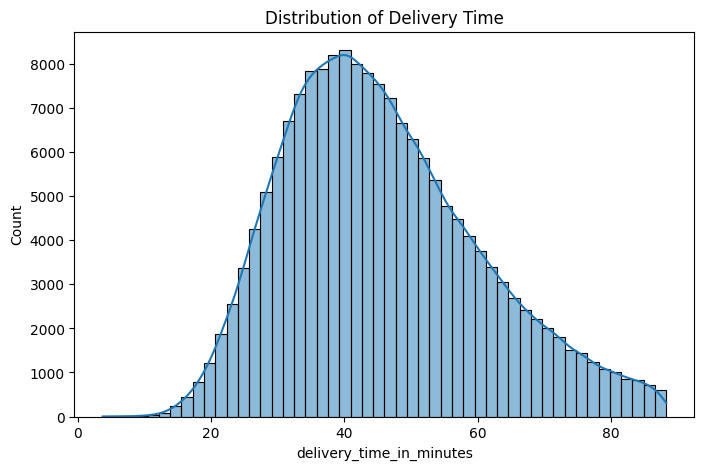

In [33]:
### Data visualization after removing outliers
plt.figure(figsize=(8, 5))
sns.histplot(filtered_data['delivery_time_in_minutes'], bins=50, kde=True)
plt.title('Distribution of Delivery Time')
plt.show()

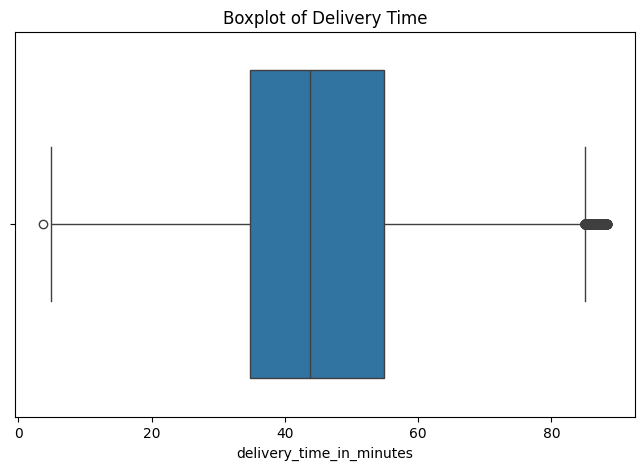

In [34]:
### after removing outliers
plt.figure(figsize=(8, 5))
sns.boxplot(x=filtered_data['delivery_time_in_minutes'])
plt.title('Boxplot of Delivery Time')
plt.show()

In [35]:
### Splitting data
X = filtered_data.drop(columns=['created_at', 'actual_delivery_time', 'delivery_time_in_minutes'])
y = filtered_data['delivery_time_in_minutes']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [36]:
### Ensure all columns are numeric before scaling
print("Columns before scaling:", X_train.dtypes)

Columns before scaling: market_id                   float64
store_primary_category      float64
order_protocol              float64
total_items                   int64
subtotal                      int64
num_distinct_items            int64
min_item_price                int64
max_item_price                int64
total_onshift_partners      float64
total_busy_partners         float64
total_outstanding_orders    float64
order_hour                    int32
order_day                     int32
order_to_partner_ratio      float64
dtype: object


In [37]:
### Check for NaN or infinite values before scaling
print("Checking for NaN values:")
print(X_train.isna().sum())
print('------------------------------------')
print("Checking for infinite values:")
print((X_train == np.inf).sum())


Checking for NaN values:
market_id                   0
store_primary_category      0
order_protocol              0
total_items                 0
subtotal                    0
num_distinct_items          0
min_item_price              0
max_item_price              0
total_onshift_partners      0
total_busy_partners         0
total_outstanding_orders    0
order_hour                  0
order_day                   0
order_to_partner_ratio      0
dtype: int64
------------------------------------
Checking for infinite values:
market_id                   0
store_primary_category      0
order_protocol              0
total_items                 0
subtotal                    0
num_distinct_items          0
min_item_price              0
max_item_price              0
total_onshift_partners      0
total_busy_partners         0
total_outstanding_orders    0
order_hour                  0
order_day                   0
order_to_partner_ratio      0
dtype: int64


###

In [39]:
### Scaling the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train.astype(float))
X_test = scaler.transform(X_test.astype(float))

In [40]:
### Hyperparameter tuning with Keras Tuner

def build_tuned_model(hp):
    model = Sequential()
    model.add(Dense(hp.Int('units_1', min_value=64, max_value=256, step=32), 
                    kernel_initializer=hp.Choice('kernel_init', ['he_normal', 'glorot_normal', 'random_uniform']),
                    kernel_regularizer=l2(hp.Float('l2_lambda', min_value=1e-5, max_value=1e-2, sampling='LOG')),
                    input_shape=(X_train.shape[1],)))
    model.add(LeakyReLU(alpha=0.1))
    # model.add(BatchNormalization())
    model.add(Dropout(hp.Float('dropout_1', min_value=0.1, max_value=0.5, step=0.1)))
    
    for i in range(hp.Int('num_layers', 1, 3)):
        model.add(Dense(hp.Int(f'units_{i+2}', min_value=32, max_value=128, step=32),
                        kernel_initializer=hp.Choice(f'kernel_init_{i+2}', ['he_normal', 'glorot_normal', 'random_uniform']),
                        kernel_regularizer=l2(hp.Float(f'l2_lambda_{i+2}', min_value=1e-5, max_value=1e-2, sampling='LOG'))))
        model.add(LeakyReLU(alpha=0.1))
        model.add(BatchNormalization())
        model.add(Dropout(hp.Float(f'dropout_{i+2}', min_value=0.1, max_value=0.5, step=0.1)))
    
    model.add(Dense(1))
    model.compile(
        optimizer=Adam(learning_rate=hp.Float('learning_rate', min_value=1e-5, max_value=1e-3, sampling='LOG')),
        loss='mse',
        metrics=['mae', 'mse', 'mape']
    )
    return model

In [42]:
### Delete previous tuner logs to force fresh tuning
shutil.rmtree('kt_tuning', ignore_errors=True)

In [43]:
### Keras Tuner - Hyperparameter Search
tuner = kt.RandomSearch(
    build_tuned_model,
    objective='val_loss',
    max_trials=10,
    executions_per_trial=1,
    directory='kt_tuning',
    project_name='porter_nn_regression'
)

tuner.search(X_train, y_train, epochs=50, validation_data=(X_test, y_test), batch_size=128, callbacks=[EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True), ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-5)])


Trial 10 Complete [00h 05m 28s]
val_loss: 204.68484497070312

Best val_loss So Far: 158.50469970703125
Total elapsed time: 00h 57m 57s


In [44]:
### Get Best Model
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"Best hyperparameters: {best_hps.values}")

best_model = tuner.hypermodel.build(best_hps)
history = best_model.fit(X_train, y_train, epochs=300, validation_data=(X_test, y_test), batch_size=128, callbacks=[EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True), ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-5)])



Best hyperparameters: {'units_1': 160, 'kernel_init': 'he_normal', 'l2_lambda': 0.0007097617582794739, 'dropout_1': 0.30000000000000004, 'num_layers': 2, 'units_2': 96, 'kernel_init_2': 'glorot_normal', 'l2_lambda_2': 4.188561619023862e-05, 'dropout_2': 0.30000000000000004, 'learning_rate': 0.0005651796781587945, 'units_3': 96, 'kernel_init_3': 'glorot_normal', 'l2_lambda_3': 1.4728347266262592e-05, 'dropout_3': 0.1, 'units_4': 64, 'kernel_init_4': 'random_uniform', 'l2_lambda_4': 1.0208172454510282e-05, 'dropout_4': 0.5}


C:\Users\VEERANNA\anaconda3\envs\py311\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
C:\Users\VEERANNA\anaconda3\envs\py311\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Epoch 1/300
1067/1067 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - loss: 1724.1869 - mae: 38.1617 - mape: 83.9083 - mse: 1723.9552 - val_loss: 180.3757 - val_mae: 10.3327 - val_mape: 23.4695 - val_mse: 180.1441 - learning_rate: 5.6518e-04
Epoch 2/300
1067/1067 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 186.4961 - mae: 10.7218 - mape: 25.4527 - mse: 186.2645 - val_loss: 168.8581 - val_mae: 10.2358 - val_mape: 24.8841 - val_mse: 168.6265 - learning_rate: 5.6518e-04
Epoch 3/300
1067/1067 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - loss: 181.3201 - mae: 10.6549 - mape: 25.9545 - mse: 181.0886 - val_loss: 167.0390 - val_mae: 10.2031 - val_mape: 24.8518 - val_mse: 166.8076 - learning_rate: 5.6518e-04
Epoch 4/300
1067/1067 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 179.7322 - mae: 10.6111 - mape: 25.8323 - mse: 179.5010 - val_loss: 168.1615 - val_mae: 10.1662 - val_mape: 24.5535 - val_mse: 167.9304 - learning_rate: 5.6518e-04
Epoch 5/300
1067/1067 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 177.6004 - mae: 10.5623 -

In [45]:
### Predictions and evaluation for the best Neural Network
y_pred = best_model.predict(X_test)
print("Optimized Neural Network Performance:")
print(f'MSE: {mean_squared_error(y_test, y_pred):.2f}')
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}')
print(f'MAE: {mean_absolute_error(y_test, y_pred):.2f}')
print(f'R2 Score: {r2_score(y_test, y_pred):.2f}')

1067/1067 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
Optimized Neural Network Performance:
MSE: 156.08
RMSE: 12.49
MAE: 9.86
R2 Score: 0.28


In [46]:
# ### Callbacks for improved training
# early_stopping = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
# reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-5)


In [47]:
# ### Keras Tuner - Hyperparameter Search
# tuner = kt.RandomSearch(
#     build_tuned_model,
#     objective='val_loss',
#     max_trials=10,
#     executions_per_trial=1,
#     directory='kt_tuning',
#     project_name='porter_nn_regression'
# )
# tuner.search(X_train, y_train, epochs=50, validation_data=(X_test, y_test), batch_size=128, callbacks=[early_stopping, reduce_lr])

In [48]:
# ### Get Best Model
# best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
# print(f"Best hyperparameters: {best_hps.values}")

# best_model = tuner.hypermodel.build(best_hps)
# history = best_model.fit(X_train, y_train, epochs=300, validation_data=(X_test, y_test), batch_size=128, callbacks=[early_stopping, reduce_lr])


In [49]:
# ### Predictions and evaluation for the best Neural Network
# y_pred = best_model.predict(X_test)
# print("Optimized Neural Network Performance:")
# print(f'MSE: {mean_squared_error(y_test, y_pred):.2f}')
# print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}')
# print(f'MAE: {mean_absolute_error(y_test, y_pred):.2f}')
# print(f'R2 Score: {r2_score(y_test, y_pred):.2f}')


# Done

In [51]:
print("Completed...!!!")

Completed...!!!


In [52]:
# ### Plot training history
# plt.figure(figsize=(8, 5))
# plt.plot(history.history['loss'], label='Train Loss')
# plt.plot(history.history['val_loss'], label='Validation Loss')
# plt.legend()
# plt.title('Loss Curve')
# plt.show()

In [53]:
# ### Export processed data to Excel
# data.to_excel("processed_porter_data.xlsx", index=False)

In [54]:
# ### Predictions and evaluation for Neural Network
# y_pred = model.predict(X_test)
# print("Neural Network Performance:")
# print(f'MSE: {mean_squared_error(y_test, y_pred):.2f}')
# print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}')
# print(f'MAE: {mean_absolute_error(y_test, y_pred):.2f}')
# print(f'R2 Score: {r2_score(y_test, y_pred):.2f}')


In [55]:
# ### Train Random Forest Regressor
# rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
# rf_model.fit(X_train, y_train)

In [56]:
# ### Predictions and evaluation for Random Forest
# y_pred_rf = rf_model.predict(X_test)
# print("Random Forest Regressor Performance:")
# print(f'MSE: {mean_squared_error(y_test, y_pred_rf):.2f}')
# print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_rf)):.2f}')
# print(f'MAE: {mean_absolute_error(y_test, y_pred_rf):.2f}')
# print(f'R2 Score: {r2_score(y_test, y_pred_rf):.2f}')

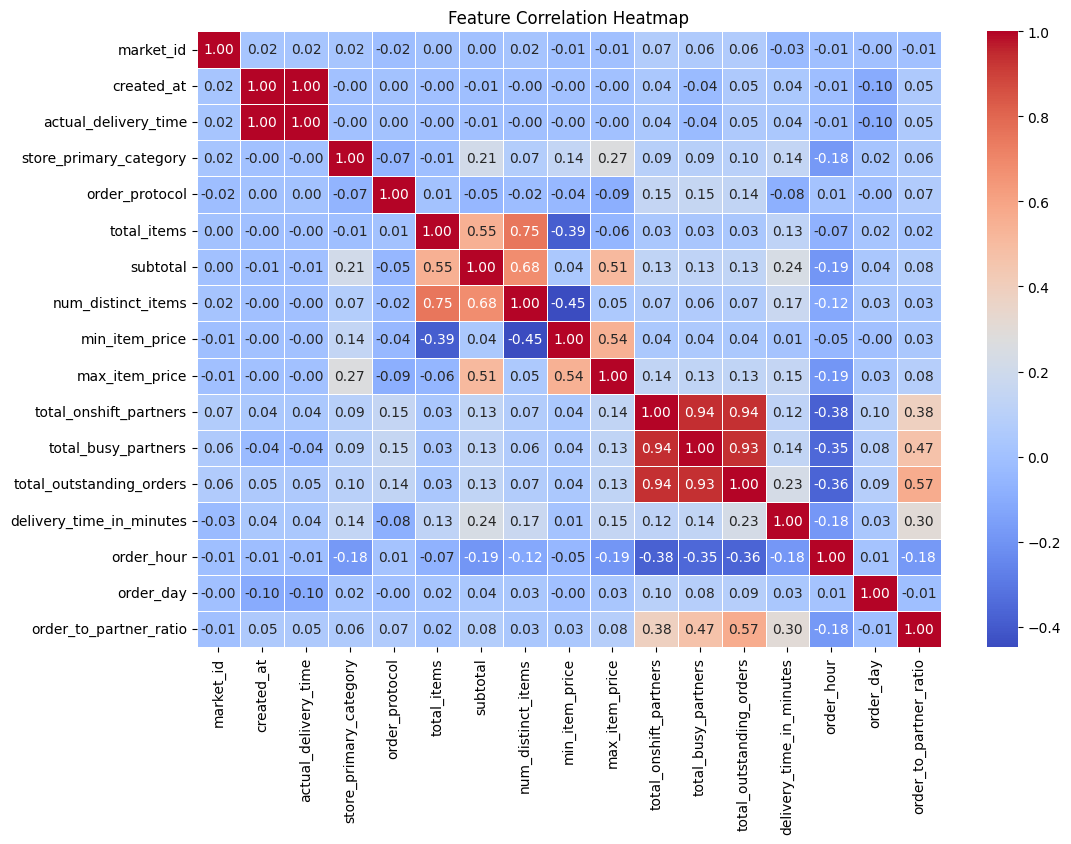

In [57]:
### Correlation Heatmap
plt.figure(figsize=(12, 8))
corr_matrix = filtered_data.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()

In [58]:
import sys
print(sys.version)

3.11.11 | packaged by Anaconda, Inc. | (main, Dec 11 2024, 16:34:19) [MSC v.1929 64 bit (AMD64)]
